In [1]:
import ToyMaker as tmkr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import os

In [2]:
%%time
def k_r():
    return 2.

def gamma_r(Xr):
    return (1/5) * Xr

species = {
            't':    0., 
            'cell': 0,
            'size': tmkr.birth_size(),
            'Xr': 0.,
}
reactions = {

    k_r: {'create': ['Xr']},
    gamma_r:{'destroy': ['Xr']},
    'division': {'segregate': ['Xr']}
}

tmax = 720
sampling_time = 1
cell = 1
cells = 10000

sim = tmkr.Simulate_Division(species, reactions, tmax, sampling_time, cell, doubling_time=18., noise_at_division=True)
# [print(sim[i]) for i in range(len(sim))];

CPU times: user 128 ms, sys: 878 µs, total: 129 ms
Wall time: 122 ms


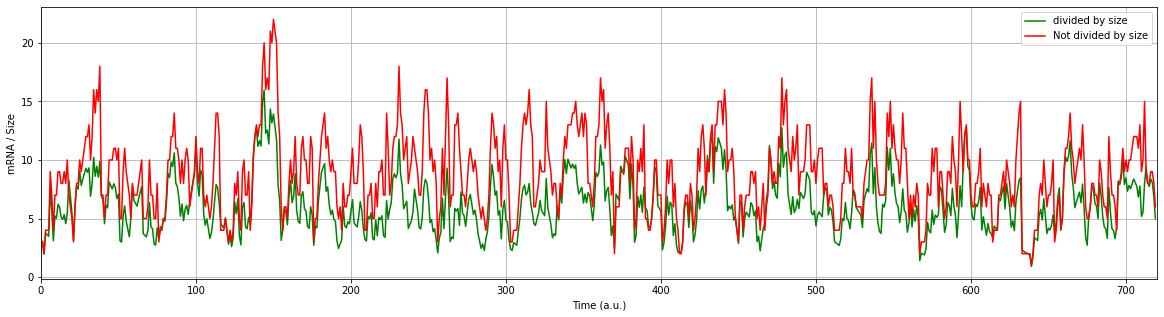

In [3]:
fig, ax = plt.subplots(figsize=(20,5))
plt.plot(sim[:,0],sim[:,3]/sim[:,2], label='divided by size', color='green')
plt.plot(sim[:,0],sim[:,3], label='Not divided by size', color='red')
plt.xlim(0, tmax)
plt.xlabel('Time (a.u.)')
plt.ylabel('mRNA / Size')
plt.grid(True)
plt.legend(loc='best')

Text(0, 0.5, 'Size')

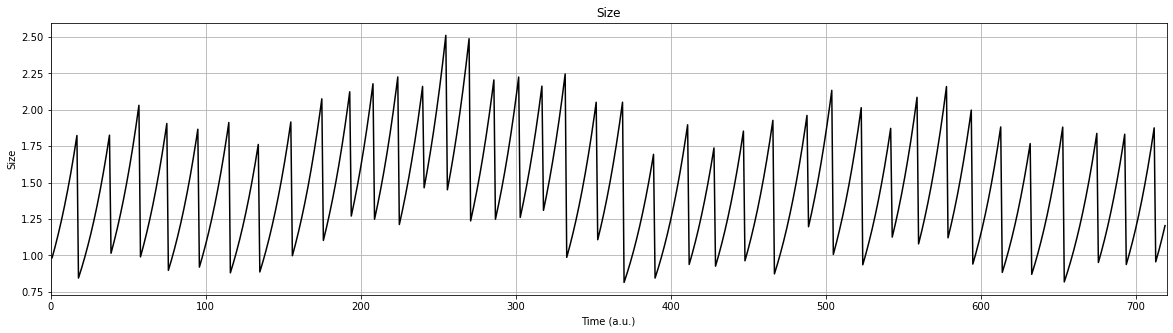

In [4]:
fig, ax = plt.subplots(figsize=(20,5))
plt.plot(sim[:,0], sim[:,2],label='Cell Size', color='black')
plt.title('Size')
plt.grid(True)
plt.xlim(0, tmax)
plt.xlabel('Time (a.u.)')
plt.ylabel('Size')

In [5]:
%%time
sims = [tmkr.Simulate_Division(species, reactions, tmax, sampling_time, c) for c in tqdm(range(1, cells + 1))]

100%|██████████| 10000/10000 [14:34<00:00, 11.44it/s]

CPU times: user 14min 42s, sys: 32.1 s, total: 15min 14s
Wall time: 14min 34s


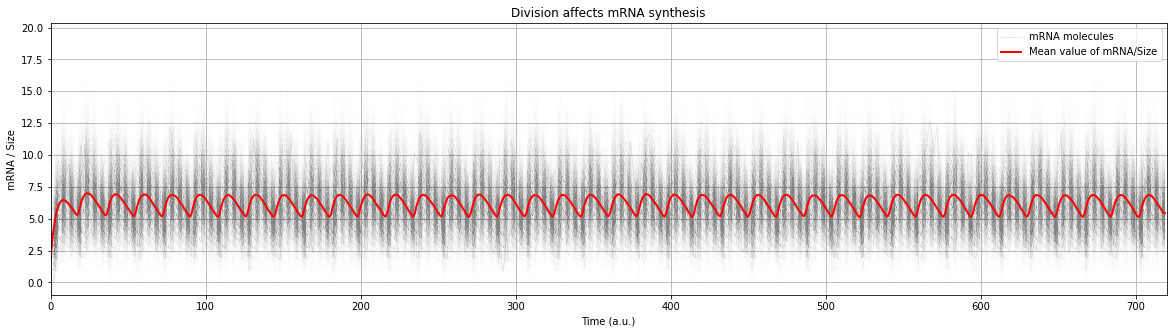

In [6]:
fig, ax = plt.subplots(figsize=(20,5))

time_arr = [sims[c][:,0] for c in range(cells)]
size_arr = [sims[c][:,2] for c in range(cells)]
rna_arr = [sims[c][:,3] for c in range(cells)]

mean_mrna = tmkr.get_mean_per_cell_division(cells=sims, samples=cells, tmax=tmax, species_idx=3, size_idx=2, single_value=False)

[plt.plot(time_arr[c], rna_arr[c]/size_arr[c], lw=0.01, color='grey', alpha=0.2) for c in range(cells if cells <= 1000 else 1000)];
plt.plot(time_arr[0], rna_arr[0]/size_arr[0], lw=0.8, color='grey', label='mRNA molecules', alpha=0.2)
plt.plot(mean_mrna, color='red', lw=2,label='Mean value of mRNA/Size')
plt.xlabel('Time (a.u.)')
plt.ylabel('mRNA / Size')
plt.xlim(0, tmax)
# plt.ylim(0, 30)
# plt.hlines((k_r()/gamma_r()), 0, tmax, color='red', label='Theoretical mRNA levels at steady state')
plt.title('Division affects mRNA synthesis')
plt.legend(loc='upper right')
plt.grid(True)

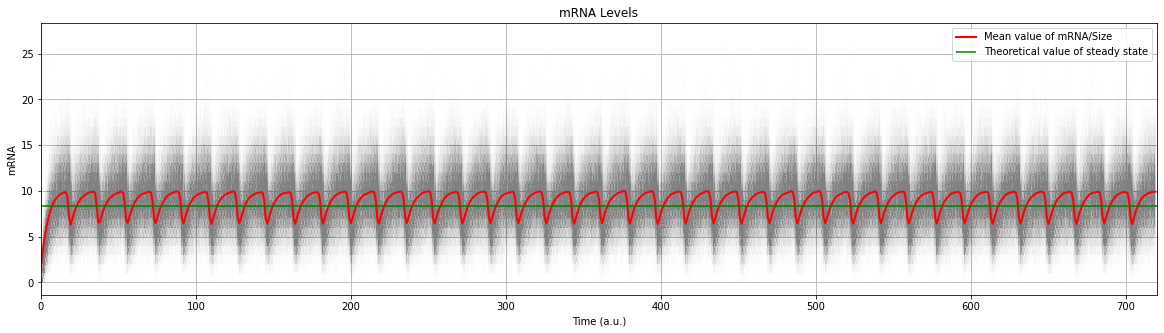

In [7]:
fig, ax = plt.subplots(figsize=(20,5))

time_arr = [sims[c][:,0] for c in range(cells)]
size_arr = [sims[c][:,2] for c in range(cells)]
rna_arr = [sims[c][:,3] for c in range(cells)]

mu = np.log(2)/18.

mean_mrna_cl = tmkr.get_mean_per_cell(cells=sims, samples=cells, tmax=tmax, species_idx=3)
# mean_mrna = tmkr.get_mean_per_cell_division(cells=sims, samples=cells, tmax=tmax, species_idx=3, size_idx=2, single_value=False)
[plt.plot(time_arr[c], rna_arr[c], lw=0.05, color='grey', alpha=0.05) for c in range(cells if cells <= 1000 else 1000)];
plt.plot(mean_mrna_cl, color='red', lw=2,label='Mean value of mRNA/Size')
plt.hlines(k_r()/(gamma_r(Xr=1.) + mu), 0, tmax, color='green', label='Theoretical value of steady state')
plt.title('mRNA Levels')
plt.xlabel('Time (a.u.)')
plt.ylabel('mRNA')
plt.legend(loc='upper right')
plt.xlim(0, tmax)
plt.grid(True)

## Steady State

#### Theoretical

In [8]:
mu = np.log(2)/18.
ss_d = k_r()/(gamma_r(Xr=1.) + mu)
ss_d

8.385456749075303

#### Simulation: 

In [9]:
mean_mrna_c = tmkr.get_mean_per_cell(cells=sims, samples=cells, tmax=tmax, species_idx=3, single_value=True)
mean_mrna_c

8.916407999999999

In [10]:
mean_mrna_d = tmkr.get_mean_per_cell_division(cells=sims, samples=cells, tmax=tmax, species_idx=3, size_idx=2, single_value=True)
mean_mrna_d

6.141524105338126

### Multiple Sims Test

In [11]:
%%time
# tmkr.multiple_sims_for_division(species, reactions, tmax, sampling_time, cells=cells, doubling_time=18., file_name='division_test.csv')

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 3.58 µs


### Storage Test

In [12]:
%%time
file_name = 'my_model'

def set_local_to_save(filename, species):
    if os.path.exists(f'{filename}.csv'):
        os.remove(f'{filename}.csv')
        with open(f'{filename}.csv', 'a') as f: 
            header = ','.join(tmkr.get_species_names(species)) + '\n'
            f.write(header)
    else:
        with open(f'{filename}.csv', 'a') as f: 
            header = ','.join(tmkr.get_species_names(species)) + '\n'
            f.write(header)

def simple_save(sims,file_name):
    with open(f'{file_name}.csv', 'a') as f:
        cells = [pd.DataFrame(cell) for cell in sims]
        [cell.to_csv(f, index=False, header=False, mode='a') for cell in cells]

def save_data(cells_arr,file_name):
    
    cells_arr = np.array(cells_arr)
    cells_arr = np.concatenate(cells_arr, axis=0)
    cells_arr = pd.DataFrame(cells_arr)
    
    with open(f'{file_name}.csv', 'a') as f:
        cells_arr.to_csv(f, index=False, header=False, mode='a')

# set_local_to_save(file_name, species)
# simple_save(sims, file_name)
# # save_data(sims, file_name)

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 5.48 µs
